In [120]:
import pandas as pd
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context('poster')

In [122]:
bids_folder = Path('/data/ds-neuralpriors')
fig_folder = bids_folder / 'derivatives' / 'figures' / 'figure3'
fig_folder.mkdir(parents=True, exist_ok=True)

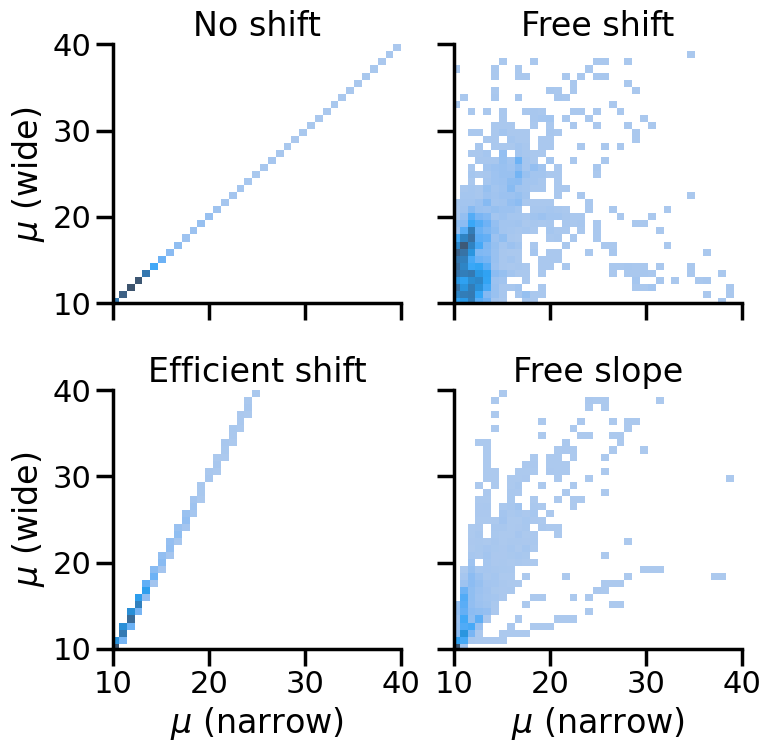

In [210]:
import pandas as pd

# Load the data
pars = pd.read_csv(
    bids_folder / 'derivatives' / 'encoding_models2' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv',
    sep='\t',
    index_col=[0, 1, 2, 3],
    header=[0, 1]
)

# Rename index levels for clarity
pars.index.set_names('subject', level='subject_id', inplace=True)

# Define the models to select and their new names
# models = [0, 3, 4, 5]
# new_model_names = ['Null model', 'Free', 'slope = 2', 'fixed slope']

models = [0, 3, 4, 5]
new_model_names = ['No shift', 'Free shift', 'Efficient shift', 'Free slope']

# Select the specified models and concatenate
pars = pd.concat(
    [pars.xs(m, level='model_label', drop_level=True) for m in models],
    axis=0,
    keys=new_model_names,
    names=['model_label']
)
pars_ = pars[pars[('cvr2', 'nan')] > 0.0]

g = sns.FacetGrid(pars_['mu'].reset_index(), col='model_label', col_wrap=2, height=4)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40), np.linspace(0, 40)],)

g.set(xlim=(10, 40), ylim=(10, 40), xlabel='Narrow', ylabel='Wide')

g.set(xticks=[10, 20, 30, 40], yticks=[10, 20, 30, 40])
g.set_titles('{col_name}')

g.set_xlabels('$\mu$ (narrow)')
g.set_ylabels('$\mu$ (wide)')
# Identity line
# slope = 1.
# g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k--'))
# slope = 2.
# g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k--'))


plt.savefig(
    fig_folder / 'models.pdf',
    dpi=300,
    bbox_inches='tight'
)

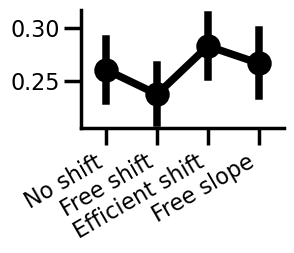

In [211]:
prop_cvr2 = pars.groupby(['model_label', 'subject']).apply(lambda d: (d[('cvr2', 'nan')] > 0.0).mean()).to_frame('Proportion cvR2 > 0.0')


g = sns.catplot(
    data=prop_cvr2.reset_index(),
    x='model_label',
    y='Proportion cvR2 > 0.0',
    kind='point',
    height=4,
    aspect=1.5,
    color='k',
    errorbar='se',
    order=new_model_names,
)

g.set(xlabel=None, ylabel=None, title=None)

# Set fontsize yticks
for label in g.ax.get_yticklabels():
    label.set_fontsize(16)

# Rotate x-ticks
for label in g.ax.get_xticklabels():
    label.set_rotation(30)
    label.set_horizontalalignment('right')
    label.set_fontsize(16)

# Make figure square
g.fig.set_size_inches(3, 2)

g.savefig(fig_folder / 'cvr2.pdf', bbox_inches='tight')

In [125]:
import pingouin as pg
tmp = prop_cvr2.unstack('model_label').droplevel(0, axis=1)

pg.pairwise_ttests(
    data=prop_cvr2.reset_index(),
    dv='Proportion cvR2 > 0.0',
    within=['model_label'],
    subject='subject',
    padjust='fdr_by'
)

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,model_label,Free slope,Null model,True,True,1.031274,38.0,two-sided,3.089316e-01,7.568823e-01,fdr_by,0.283,0.032659
1,model_label,Free slope,Slope=2,True,True,-3.945911,38.0,two-sided,3.314360e-04,1.218027e-03,fdr_by,82.693,-0.085308
2,model_label,Free slope,Voxelwise,True,True,5.430017,38.0,two-sided,3.442521e-06,2.530253e-05,fdr_by,5414.501,0.159274
3,model_label,Null model,Slope=2,True,True,-4.181816,38.0,two-sided,1.640465e-04,8.038280e-04,fdr_by,156.101,-0.121280
4,model_label,Null model,Voxelwise,True,True,3.431578,38.0,two-sided,1.461344e-03,4.296351e-03,fdr_by,21.969,0.129329
5,model_label,Slope=2,Voxelwise,True,True,8.194716,38.0,two-sided,6.336749e-10,9.315021e-09,fdr_by,1.755e+07,0.254860


                     Proportion cvR2 > 0.0
model_label subject                       
Free slope  1                     0.112840
            2                     0.111628
            3                     0.040616
            4                     0.285161
            5                     0.057607
...                                    ...
Voxelwise   37                    0.181704
            38                    0.628205
            39                    0.551839
            40                    0.064660
            41                    0.567723

[156 rows x 1 columns]


In [ ]:
pars = pars[pars[('cvr2', 'nan')] > 0.0]

g = sns.FacetGrid(pars['mu'].reset_index(), col='model_label')

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40), np.linspace(0, 40)],)

g.set(xlim=(10, 40), ylim=(10, 40))

g.set_titles('{col_name}')

# Identity line
slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k--'))

subject  model_label    
1        Fixed slope (2)    0.140078
         Free slope         0.112840
         Null model         0.115435
         Voxelwise          0.093385
2        Fixed slope (2)    0.126744
                              ...   
40       Voxelwise          0.064660
41       Fixed slope (2)    0.587896
         Free slope         0.613833
         Null model         0.577810
         Voxelwise          0.567723
Length: 156, dtype: float64

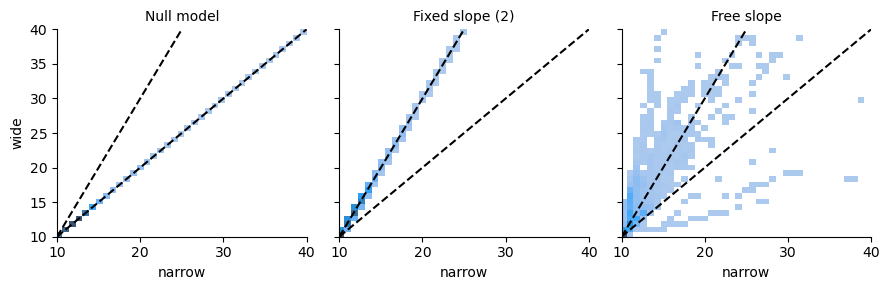

In [ ]:
g = sns.FacetGrid(pars['mu'].reset_index(), col='model_label')

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40), np.linspace(0, 40)],)

g.set(xlim=(10, 40), ylim=(10, 40))

g.set_titles('{col_name}')

# Identity line
slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k--'))

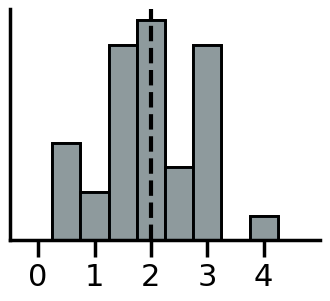

In [152]:
sns.histplot(pars.loc['Free slope']['delta_wide'].groupby('subject').mean(), legend=False, color='k',
             bins=np.arange(-.25, 5, .5),)

sns.despine()

plt.ylabel('')
plt.yticks([])

plt.gcf().set_size_inches(4, 3)

plt.xticks([0, 1, 2, 3, 4])

plt.axvline(2.0, c='k', ls='--')

# plt.title("Estimated slopes\nwide ~ narrow")

plt.savefig(
    fig_folder / 'slope.pdf',
    dpi=300,
    bbox_inches='tight'
)

In [156]:
pg.ttest(pars.loc['Free slope']['delta_wide'].groupby('subject').mean()['narrow'], 1.0)

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: overflow encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: overflow encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.419399,38,two-sided,0.000004,"[1.87, 2.9]",0.867798,5249.123,0.999547


In [157]:
pg.ttest(pars.loc['Free slope']['delta_wide'].groupby('subject').mean()['narrow'], 2.0)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.498341,38,two-sided,0.142307,"[1.87, 2.9]",0.239927,0.482,0.309058


In [158]:
1./0.482

2.074688796680498

(0.0, 0.41888939442150436)

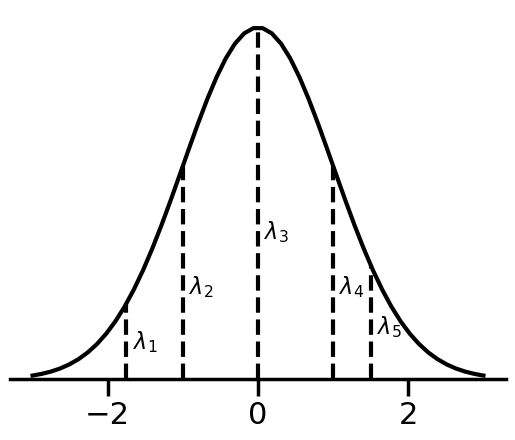

In [178]:
import scipy.stats as ss


x = np.linspace(-3, 3)
dist = ss.norm(0, 1.)

plt.plot(x, dist.pdf(x), label='Normal(0, 1)', c='k')

sns.despine(left=True)
plt.yticks([])

thresholds = [-1.75, -1., 0, 1., 1.5,]

for i, t in enumerate(thresholds):
    plt.plot([t, t], [0, dist.pdf(t)], c='k', ls='--')

    plt.annotate(
        f'$\lambda_{i+1}$',
        xy=(t, dist.pdf(t)),
        xytext=(t+.25, dist.pdf(t) / 2.5),
        ha='center',
        fontsize=16,
        color='k'
    )


plt.ylim(0, None)

(-3.0, 3.0)

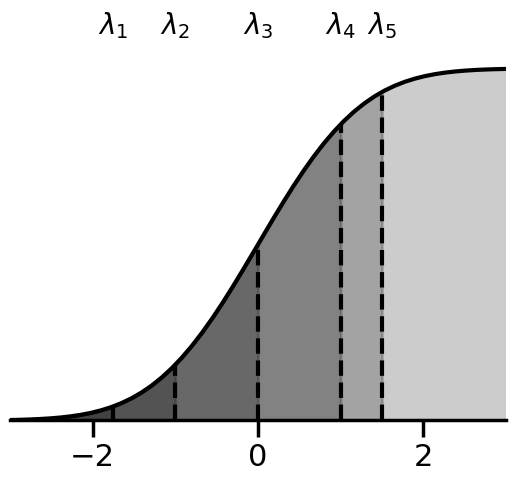

In [207]:
import scipy.stats as ss


x = np.linspace(-3, 3)
dist = ss.norm(0, 1.)

plt.plot(x, dist.cdf(x), label='Normal(0, 1)', c='k')

sns.despine(left=True)
plt.yticks([])

thresholds = [-1.75, -1., 0, 1., 1.5, 4]

for i, t in enumerate(thresholds):
    plt.plot([t, t], [0, dist.cdf(t)], c='k', ls='--')


    x_ = np.linspace(-3, t)
    plt.fill_between(x_, dist.cdf(x_), 0, color='k', alpha=.2)


    if i < 5:
        plt.text(t, 1.1, f'$\lambda_{i+1}$', color='k', fontsize=20, ha='center')


#     plt.annotate(
#         f'$\lambda_{i+1}$',
#         xy=(t, dist.pdf(t)),
#         xytext=(t+.25, dist.pdf(t) / 2.5),
#         ha='center',
#         fontsize=16,
#         color='k'
#     )


plt.ylim(0.0, None)
plt.xlim(-3, 3.)

In [190]:
plt.text?

Signature:
plt.text(
    x: 'float',
    y: 'float',
    s: 'str',
    fontdict: 'dict[str, Any] | None' = None,
    **kwargs,
) -> 'Text'
Docstring:
Add text to the Axes.

Add the text *s* to the Axes at location *x*, *y* in data coordinates,
with a default ``horizontalalignment`` on the ``left`` and
``verticalalignment`` at the ``baseline``. See
:doc:`/gallery/text_labels_and_annotations/text_alignment`.

Parameters
----------
x, y : float
    The position to place the text. By default, this is in data
    coordinates. The coordinate system can be changed using the
    *transform* parameter.

s : str
    The text.

fontdict : dict, default: None

    .. admonition:: Discouraged

       The use of *fontdict* is discouraged. Parameters should be passed as
       individual keyword arguments or using dictionary-unpacking
       ``text(..., **fontdict)``.

    A dictionary to override the default text properties. If fontdict
    is None, the defaults are determined by `.rcParams`.

Retur

In [184]:
plt.fill_between?

Signature:
plt.fill_between(
    x: 'ArrayLike',
    y1: 'ArrayLike | float',
    y2: 'ArrayLike | float' = 0,
    where: 'Sequence[bool] | None' = None,
    interpolate: 'bool' = False,
    step: "Literal['pre', 'post', 'mid'] | None" = None,
    *,
    data=None,
    **kwargs,
) -> 'PolyCollection'
Docstring:
Fill the area between two horizontal curves.

The curves are defined by the points (*x*, *y1*) and (*x*,
*y2*).  This creates one or multiple polygons describing the filled
area.

You may exclude some horizontal sections from filling using *where*.

By default, the edges connect the given points directly.  Use *step*
if the filling should be a step function, i.e. constant in between
*x*.

Parameters
----------
x : array (length N)
    The x coordinates of the nodes defining the curves.

y1 : array (length N) or scalar
    The y coordinates of the nodes defining the first curve.

y2 : array (length N) or scalar, default: 0
    The y coordinates of the nodes defining the second cu